# XGBoost Experiments

**Objective:**

This notebook evaluates the performance of the XGBoost model using different strategies to handle class imbalance:

- Baseline
- Class-weight
- SMOTE
- SMOTEENN

**All experiments use:**
- A shared preprocessing pipeline
- Stratified K-Fold cross-validation
- A unified evaluation framework

Results are stored in a shared results table for comparison with other models.

## Setup

In [2]:
# Add project root to system path so we can import from src/
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent.parent / "bank-deposit-prediction"
sys.path.append(str(PROJECT_ROOT))


# Standard libraries
import pandas as pd

# Modeling
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# Imbalanced learning tools
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

# Shared project modules
from src.shared import get_cv, get_preprocessing_steps, Pipeline
from src.evaluation import evaluate_model, save_results



## Data Loading

In [3]:
data_path = PROJECT_ROOT / "data" / "raw" / "bank2.csv"

df = pd.read_csv(data_path, sep=';')

y = df['y'].map({'yes': 1, 'no': 0})
X = df.drop(columns=['y'])

## Shared components

We use:
- A centralized preprocessing pipeline (no data leakage)
- Stratified K-Fold cross-validation for fair evaluation

In [129]:
# Get shared cross-validation strategy
cv = get_cv()

## Baseline XGBoost

- No imbalance handling
- Serves as a reference model

In [ ]:
all_results = []

# Build baseline pipeline
xgb_baseline_pipeline = Pipeline(
    get_preprocessing_steps() +  # Apply preprocessing
    [('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

# Evaluate model
result_baseline  = evaluate_model("XGBoost", "Baseline", xgb_baseline_pipeline, X, y, cv)
all_results.append(result_baseline)
result_baseline

{'Model': 'XGBoost',
 'Strategy': 'Baseline',
 'Accuracy': '0.8830 ± 0.0048',
 'Precision': '0.4765 ± 0.0576',
 'Recall': '0.1784 ± 0.0353',
 'F1': '0.2590 ± 0.0447',
 'PR-AUC': '0.3037 ± 0.0329',
 'ROC-AUC': '0.7020 ± 0.0049'}

## Class Weight (Imbalance Handling)

- Adjusts model to penalize misclassification of minority class
- Uses scale_pos_weight

In [ ]:
# Compute class weight ratio
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

xgb_cw_pipeline = Pipeline(
    get_preprocessing_steps() +
    [('model', XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ))
])

result_cw = evaluate_model("XGBoost", "ClassWeight", xgb_cw_pipeline, X, y, cv)
all_results.append(result_cw)
result_cw

{'Model': 'XGBoost',
 'Strategy': 'ClassWeight',
 'Accuracy': '0.8498 ± 0.0070',
 'Precision': '0.3300 ± 0.0308',
 'Recall': '0.2936 ± 0.0394',
 'F1': '0.3099 ± 0.0313',
 'PR-AUC': '0.2791 ± 0.0381',
 'ROC-AUC': '0.6806 ± 0.0194'}

## SMOTE (Oversampling)

- Generates synthetic samples for the minority class
- Applied inside the pipeline to avoid data leakage

In [ ]:
xgb_smote_pipeline = ImbPipeline(
    get_preprocessing_steps() +
    [('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

result_smote = evaluate_model("XGBoost", "SMOTE", xgb_smote_pipeline, X, y, cv)
all_results.append(result_smote)
result_smote

{'Model': 'XGBoost',
 'Strategy': 'SMOTE',
 'Accuracy': '0.8834 ± 0.0023',
 'Precision': '0.4829 ± 0.0311',
 'Recall': '0.1765 ± 0.0372',
 'F1': '0.2567 ± 0.0431',
 'PR-AUC': '0.3178 ± 0.0177',
 'ROC-AUC': '0.7172 ± 0.0150'}

## SMOTEENN (Hybrid Method)

- Combines:
  - SMOTE (oversampling)
  - ENN (cleaning noisy samples)
- Aims to improve class balance and data quality

In [171]:
xgb_smoteenn_pipeline = ImbPipeline(
    get_preprocessing_steps() +
    [('smoteenn', SMOTEENN(random_state=42)),
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

result_smoteenn = evaluate_model("XGBoost", "SMOTEENN", xgb_smoteenn_pipeline, X, y, cv)
all_results.append(result_smoteenn)

result_smoteenn

{'Model': 'XGBoost',
 'Strategy': 'SMOTEENN',
 'Accuracy': '0.8290 ± 0.0041',
 'Precision': '0.3266 ± 0.0061',
 'Recall': '0.4549 ± 0.0160',
 'F1': '0.3800 ± 0.0061',
 'PR-AUC': '0.3323 ± 0.0215',
 'ROC-AUC': '0.7270 ± 0.0142'}

## Results Summary

All experiment results are stored in a shared table for comparison with other models

In [117]:
# Save results
results_df = pd.DataFrame(all_results)
save_results(results_df)

# Read experiment_results table
results_path = PROJECT_ROOT / "results" / "experiment_results.csv"
results = pd.read_csv(results_path)
results

,Model,Strategy,Accuracy,Precision,Recall,F1,PR-AUC,ROC-AUC
0,XGBoost,Baseline,0.8830 ± 0.0048,0.4765 ± 0.0576,0.1784 ± 0.0353,0.2590 ± 0.0447,0.3037 ± 0.0329,0.7020 ± 0.0049
1,XGBoost,ClassWeight,0.8498 ± 0.0070,0.3300 ± 0.0308,0.2936 ± 0.0394,0.3099 ± 0.0313,0.2791 ± 0.0381,0.6806 ± 0.0194
2,XGBoost,SMOTE,0.8834 ± 0.0023,0.4829 ± 0.0311,0.1765 ± 0.0372,0.2567 ± 0.0431,0.3178 ± 0.0177,0.7172 ± 0.0150
3,XGBoost,SMOTEENN,0.8290 ± 0.0041,0.3266 ± 0.0061,0.4549 ± 0.0160,0.3800 ± 0.0061,0.3323 ± 0.0215,0.7270 ± 0.0142
4,RandomForest,Baseline,0.8885 ± 0.0028,0.5940 ± 0.0983,0.1209 ± 0.0231,0.1989 ± 0.0308,0.3482 ± 0.0273,0.7333 ± 0.0184
5,RandomForest,ClassWeight,0.8910 ± 0.0049,0.6479 ± 0.1295,0.1151 ± 0.0303,0.1947 ± 0.0493,0.3418 ± 0.0378,0.7384 ± 0.0211
6,RandomForest,SMOTE,0.8848 ± 0.0051,0.5003 ± 0.0823,0.1516 ± 0.0294,0.2320 ± 0.0416,0.3234 ± 0.0372,0.7252 ± 0.0239
7,RandomForest,SMOTEENN,0.8275 ± 0.0083,0.3171 ± 0.0158,0.4281 ± 0.0186,0.3639 ± 0.0125,0.3064 ± 0.0331,0.7207 ± 0.0273
8,LogisticRegression,Baseline,0.8923 ± 0.0037,0.6605 ± 0.1145,0.1439 ± 0.0290,0.2342 ± 0.0399,0.3482 ± 0.0375,0.7247 ± 0.0143
9,LogisticRegression,ClassWeight,0.7125 ± 0.0128,0.2188 ± 0.0073,0.5815 ± 0.0427,0.3176 ± 0.0122,0.3407 ± 0.0344,0.7238 ± 0.0130


#### Model Selection and Stability Analysis

In [5]:
# Function to split "mean ± std"
def split_mean_std(column):
    mean = column.str.split('±').str[0].astype(float)
    std  = column.str.split('±').str[1].astype(float)
    return mean, std

# Apply to needed columns
for col in ['Recall', 'F1', 'PR-AUC']:
    results[f'{col}_mean'], results[f'{col}_std'] = split_mean_std(results[col])

In [6]:
# Filter top 2 models
top_models = results[
    (results['Model'] == 'XGBoost') & (results['Strategy'] == 'SMOTEENN') |
    (results['Model'] == 'RandomForest') & (results['Strategy'] == 'SMOTEENN')
]
top_models

,Model,Strategy,Accuracy,Precision,Recall,F1,PR-AUC,ROC-AUC,Recall_mean,Recall_std,F1_mean,F1_std,PR-AUC_mean,PR-AUC_std
3,XGBoost,SMOTEENN,0.8290 ± 0.0041,0.3266 ± 0.0061,0.4549 ± 0.0160,0.3800 ± 0.0061,0.3323 ± 0.0215,0.7270 ± 0.0142,0.4549,0.0160,0.3800,0.0061,0.3323,0.0215
7,RandomForest,SMOTEENN,0.8275 ± 0.0083,0.3171 ± 0.0158,0.4281 ± 0.0186,0.3639 ± 0.0125,0.3064 ± 0.0331,0.7207 ± 0.0273,0.4281,0.0186,0.3639,0.0125,0.3064,0.0331


In [7]:
metrics = ['Recall', 'F1', 'PR-AUC']

xgb = top_models[top_models['Model'] == 'XGBoost']
rf  = top_models[top_models['Model'] == 'RandomForest']

xgb_mean = [xgb[f'{m}_mean'].values[0] for m in metrics]
xgb_std  = [xgb[f'{m}_std'].values[0] for m in metrics]

rf_mean  = [rf[f'{m}_mean'].values[0] for m in metrics]
rf_std   = [rf[f'{m}_std'].values[0] for m in metrics]

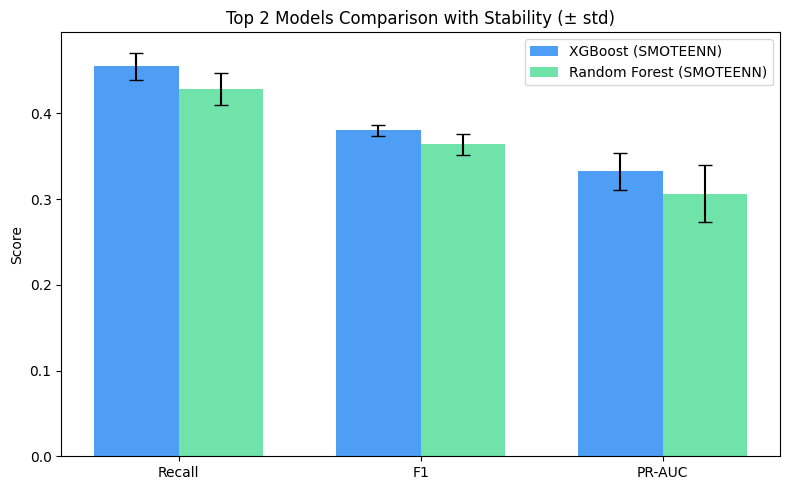

In [11]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(x - width/2, xgb_mean, width, yerr=xgb_std, color="#4F9EF5",
       label='XGBoost (SMOTEENN)', capsize=5, ecolor='black')

ax.bar(x + width/2, rf_mean, width, yerr=rf_std, color='#6FE3AA',
       label='Random Forest (SMOTEENN)', capsize=5 , ecolor='black')


ax.set_ylabel('Score')
ax.set_title('Top 2 Models Comparison with Stability (± std)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)

ax.legend()

plt.tight_layout()
plt.savefig("top_models_comparison.png", dpi=300)
plt.show()

# Evaluation & Analysis

Interpretability:
- Compare feature importance across models (top features)
- Apply SHAP for deeper explanation on the best-performing model (XGB SMOTEENN)

Threshold optimization:
Test different decision thresholds and estimate business profit to choose the optimal threshold.


## Setup

In [ ]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import train_test_split
from src.shared import drop_columns, transform_pdays


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

xgb_smoteenn_pipeline.fit(X_train, y_train)


,steps,"[('drop_columns', ...), ('pdays_transform', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function dro...0022AE5472980>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


## Top Features

In [173]:
preprocessor = xgb_smoteenn_pipeline.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

In [174]:
xgb_model = xgb_smoteenn_pipeline.named_steps['model']  

In [175]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

xgb_importance.head(10)

cat__contact_unknown        0.150656
cat__marital_married        0.046758
cat__contact_cellular       0.041526
cat__poutcome_success       0.039710
cat__month_jul              0.039430
cat__housing_yes            0.036733
cat__loan_no                0.032684
cat__education_secondary    0.032252
cat__month_may              0.026187
cat__housing_no             0.025802
dtype: float32

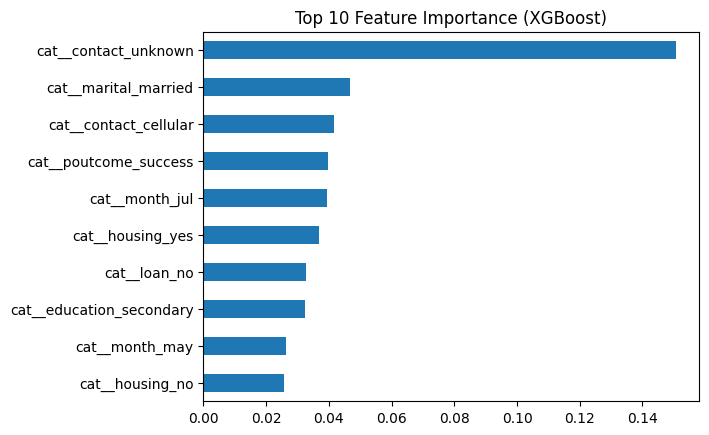

In [181]:
xgb_importance.head(10).sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importance (XGBoost)")
plt.show()

## SHAP Analysis

⏳ Training model for SHAP audit...
Generating SHAP Analysis for XGBoost SMOTEENN...


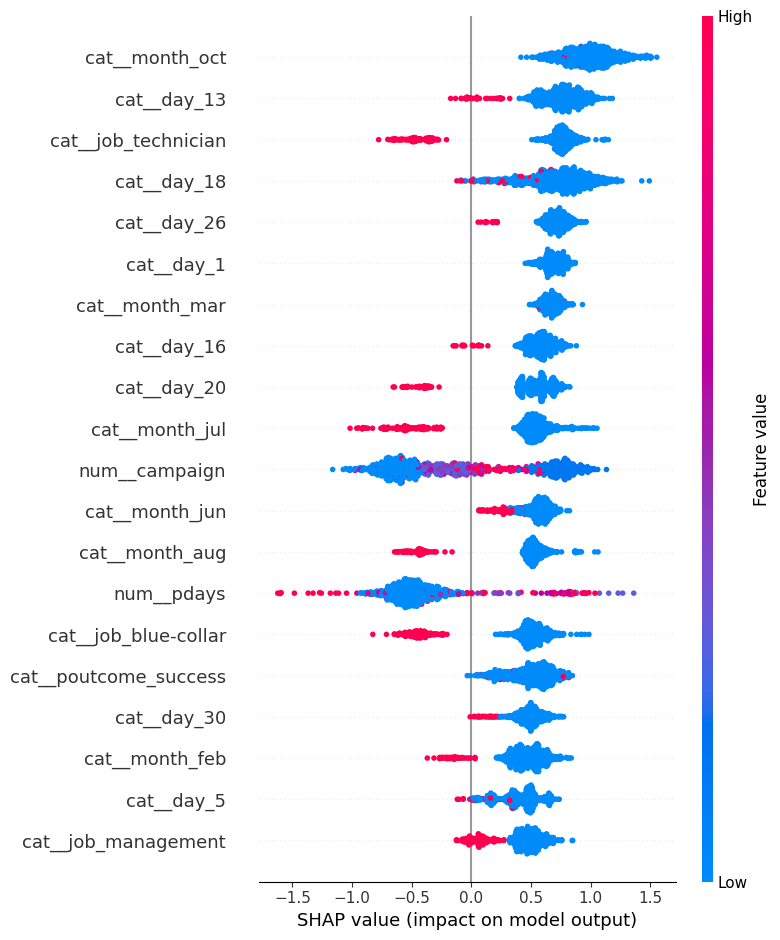

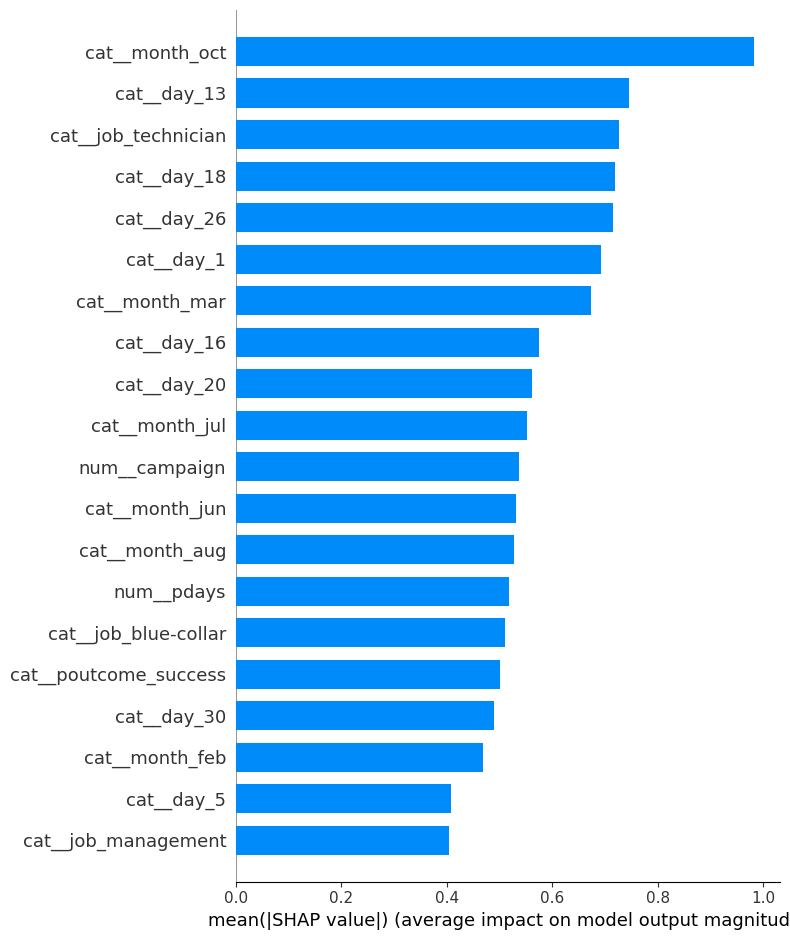

In [180]:
print("⏳ Training model for SHAP audit...")
#  Apply preprocessing 
X_temp = xgb_smoteenn_pipeline.named_steps['drop_columns'].transform(X_test)
X_temp = xgb_smoteenn_pipeline.named_steps['pdays_transform'].transform(X_temp)

X_test_transformed = xgb_smoteenn_pipeline.named_steps['preprocessor'].transform(X_temp)

#  Convert sparse → dense 
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()
else:
    X_test_transformed = X_test_transformed

#  Get feature names
feature_names = xgb_smoteenn_pipeline.named_steps['preprocessor'].get_feature_names_out()

#  Convert to DataFrame
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# 4. Explain the XGBoost Classifier
# We grab the 'classifier' step specifically
xgb_model = xgb_smoteenn_pipeline.named_steps['model']
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_df)

# 5. Final Summary Plot
print("Generating SHAP Analysis for XGBoost SMOTEENN...")
# Note: For XGBoost, we usually just pass shap_values directly
shap.summary_plot(shap_values, X_test_df)
shap.summary_plot(shap_values, X_test_df, plot_type="bar")

## Threshold optimization:

- Testing the model at every 0.01 increment
- Testing different scenarios to assess profit based on 3 different cost scenarios

In [152]:
thresholds = np.linspace(0.01, 0.99, 99)

In [164]:
scenarios = {
    "Aggressive": {"TP": 120, "FP": -15, "FN": -120},
    "Balanced": {"TP": 100, "FP": -20, "FN": -100},
    "Conservative": {"TP": 100, "FP": -50, "FN": -80}
}

def calculate_profit(y_true, y_pred, TP, FP, FN):
    profit = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == 1 and yp == 1:
            profit += TP
        elif yt == 0 and yp == 1:
            profit += FP
        elif yt == 1 and yp == 0:
            profit += FN
    return profit / len(y_true)  # normalized

In [177]:
y_probs = xgb_smoteenn_pipeline.predict_proba(X_test)[:, 1]

In [178]:
results = []

for name, costs in scenarios.items():
    best_profit = -float('inf')
    best_threshold = None

    for t in thresholds:
        y_pred = (y_probs >= t).astype(int)

        p = calculate_profit(
            y_test, y_pred,
            costs["TP"], costs["FP"], costs["FN"]
        )

        if p > best_profit:
            best_profit = p
            best_threshold = t

    results.append({
        "Scenario": name,
        "Best Threshold": best_threshold,
        "Max Profit": best_profit
    })
threshold_df = pd.DataFrame(results)
threshold_df

,Scenario,Best Threshold,Max Profit
0,Aggressive,0.05,3.033149
1,Balanced,0.12,-1.060773
2,Conservative,0.70,-6.276243


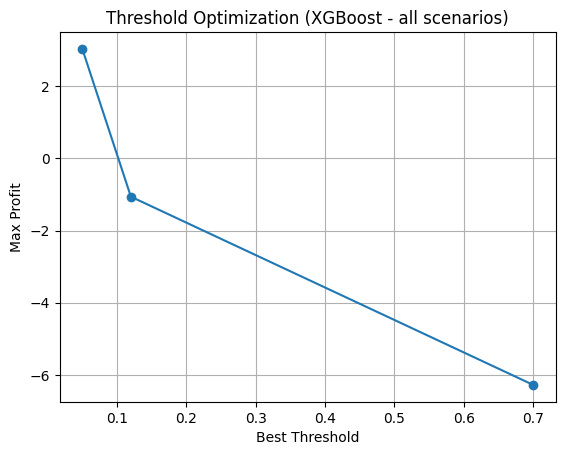

In [179]:
plt.figure()
plt.plot(threshold_df["Best Threshold"], threshold_df["Max Profit"], marker='o')

plt.xlabel("Best Threshold")
plt.ylabel("Max Profit")
plt.title("Threshold Optimization (XGBoost - all scenarios)")

plt.grid()
plt.show()